**Python Notebook 2 – Classification Modelling and Hyperparameter Tuning**

Module: 5DATA002W.2 – Machine Learning & Data Mining

Author: Shane Rowell

Peer Reviewer: Dasika Ruvishan

Review Date: 18/03/2026

Dataset: loan_approval_data.csv

**Step 1 – Import Libraries**

In [ ]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for statistical visualisation
import seaborn as sns

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler to normalise feature values
from sklearn.preprocessing import StandardScaler

# Import LabelEncoder to convert categorical text into numerical form
from sklearn.preprocessing import LabelEncoder

# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Import K-Nearest Neighbours classifier
from sklearn.neighbors import KNeighborsClassifier

# Import Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Import accuracy score for overall model performance
from sklearn.metrics import accuracy_score

# Import confusion matrix to evaluate prediction breakdown
from sklearn.metrics import confusion_matrix

# Import classification report for precision recall and F1 scores
from sklearn.metrics import classification_report

# Import ROC curve and AUC score for threshold independent evaluation
from sklearn.metrics import roc_curve, roc_auc_score

# Import GridSearchCV for hyperparameter tuning via cross validation
from sklearn.model_selection import GridSearchCV

**Step 2 – Load Dataset**

In [ ]:
# Load the raw dataset from CSV into a pandas DataFrame
df = pd.read_csv('loan_approval_data.csv')

# Display first 5 rows to confirm the data loaded correctly
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


**Step 3 – Preprocess Data for Classification**

In [ ]:
# Drop max_allowed_loan to prevent data leakage
# This value is only known after a loan decision so it must not be used as a feature
df = df.drop(columns=['max_allowed_loan'], errors='ignore')

# Drop the id column as it is a unique identifier with no predictive value
df = df.drop(columns=['id'], errors='ignore')

# Impute missing numerical values with the column mean
df['age'] = df['age'].fillna(df['age'].mean())
df['loan_interest_rate'] = df['loan_interest_rate'].fillna(df['loan_interest_rate'].mean())
df['loan_income_ratio'] = df['loan_income_ratio'].fillna(df['loan_income_ratio'].mean())
df['credit_history_length'] = df['credit_history_length'].fillna(df['credit_history_length'].mean())
df['emplyment_length'] = df['emplyment_length'].fillna(df['emplyment_length'].mean())
df['income'] = df['income'].fillna(df['income'].mean())
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].mean())

# Impute missing categorical values with the column mode
df['home_ownership'] = df['home_ownership'].fillna(df['home_ownership'].mode()[0])
df['loan_intent'] = df['loan_intent'].fillna(df['loan_intent'].mode()[0])
df['payment_default_on_file'] = df['payment_default_on_file'].fillna(df['payment_default_on_file'].mode()[0])

# Encode categorical columns into integers using LabelEncoder
le = LabelEncoder()
df['home_ownership'] = le.fit_transform(df['home_ownership'])
df['loan_intent'] = le.fit_transform(df['loan_intent'])
df['payment_default_on_file'] = le.fit_transform(df['payment_default_on_file'])

# Confirm preprocessing completed with no remaining missing values
print("Remaining missing values:", df.isnull().sum().sum())
print("Dataset shape after preprocessing:", df.shape)

Remaining missing values: 0
Dataset shape after preprocessing: (58645, 11)


**Step 4 – Define Features and Target Variable**

In [ ]:
# Define X as the input features by dropping the target column
X = df.drop(columns=['loan_approval_status'])

# Define y as the target variable we are trying to predict
y = df['loan_approval_status']

# Print the feature names and target distribution for confirmation
print("Features:", X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())

Features: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Target distribution:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64


**Step 5 – Split Data into Training and Testing Sets**

In [ ]:
# Split the data into training and testing sets
# test_size=0.2 means 20% of data is reserved for testing
# stratify=y ensures class proportions are preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print the sizes of each split to confirm
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (46916, 10)
Testing set size: (11729, 10)


**Step 6 – Feature Scaling**

In [ ]:
# Create a StandardScaler instance
scaler = StandardScaler()

# Fit the scaler on training data only and transform it
X_train = scaler.fit_transform(X_train)

# Apply the same fitted scaler to the test data without refitting
X_test = scaler.transform(X_test)

print("Feature scaling applied successfully.")

Feature scaling applied successfully.


**Step 7 – Build and Evaluate Logistic Regression Model**

In [ ]:
# Create and train the Logistic Regression model on the training data
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Print overall accuracy
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))

Logistic Regression Accuracy: 0.8902


Step 7a – Logistic Regression Confusion Matrix

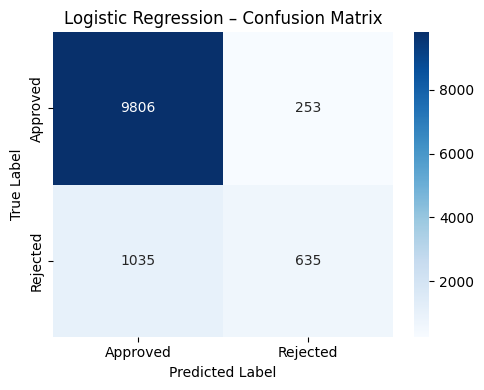

In [ ]:
# Compute the confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot the confusion matrix as a heatmap for clear visual interpretation
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])

# Add title and axis labels
plt.title('Logistic Regression – Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Step 7b – Logistic Regression Classification Report

In [ ]:
# Print the full classification report showing precision recall and F1 for each class
print("Logistic Regression – Classification Report")
print(classification_report(y_test, y_pred_lr, target_names=['Approved', 'Rejected']))

Logistic Regression – Classification Report
              precision    recall  f1-score   support

    Approved       0.90      0.97      0.94     10059
    Rejected       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



**Step 8 – Build and Evaluate K-Nearest Neighbours Model**

In [ ]:
# Create and train the KNN model with k=5 as the initial number of neighbours
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Print overall accuracy
print("KNN Accuracy:", round(accuracy_score(y_test, y_pred_knn), 4))

KNN Accuracy: 0.9142


Step 8a – KNN Confusion Matrix

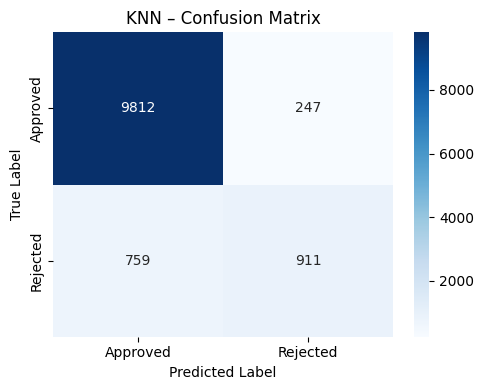

In [ ]:
# Compute the confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])

# Add title and axis labels
plt.title('KNN – Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Step 8b – KNN Classification Report

In [ ]:
# Print the full classification report for KNN
print("KNN – Classification Report")
print(classification_report(y_test, y_pred_knn, target_names=['Approved', 'Rejected']))

KNN – Classification Report
              precision    recall  f1-score   support

    Approved       0.93      0.98      0.95     10059
    Rejected       0.79      0.55      0.64      1670

    accuracy                           0.91     11729
   macro avg       0.86      0.76      0.80     11729
weighted avg       0.91      0.91      0.91     11729



**Step 9 – Build and Evaluate Naive Bayes Model**

In [ ]:
# Create and train the Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# Print overall accuracy
print("Naive Bayes Accuracy:", round(accuracy_score(y_test, y_pred_nb), 4))

Naive Bayes Accuracy: 0.8493


Step 9a – Naive Bayes Confusion Matrix

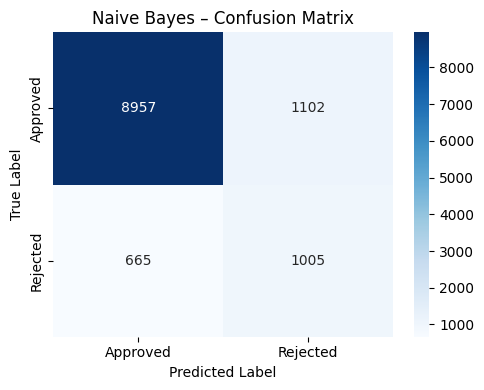

In [ ]:
# Compute the confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])

# Add title and axis labels
plt.title('Naive Bayes – Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Step 9b – Naive Bayes Classification Report

In [ ]:
# Print the full classification report for Naive Bayes
print("Naive Bayes – Classification Report")
print(classification_report(y_test, y_pred_nb, target_names=['Approved', 'Rejected']))

Naive Bayes – Classification Report
              precision    recall  f1-score   support

    Approved       0.93      0.89      0.91     10059
    Rejected       0.48      0.60      0.53      1670

    accuracy                           0.85     11729
   macro avg       0.70      0.75      0.72     11729
weighted avg       0.87      0.85      0.86     11729



**Step 10 – ROC Curve and AUC Score Comparison**

*ROC curve plots the true positive rate against the false positive rate at
various classification thresholds. The AUC score summarises the curve into a
single value where 1.0 is a perfect classifier and 0.5 is no better than random.*

Logistic Regression AUC: 0.8714
KNN AUC:                 0.8549
Naive Bayes AUC:         0.8548


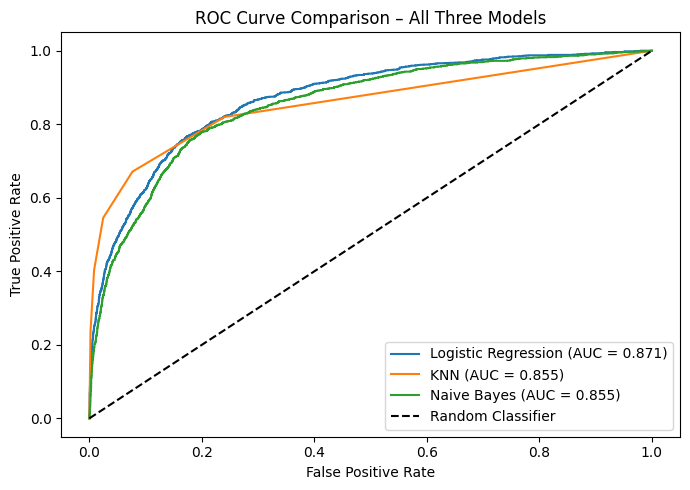

In [ ]:
# Get predicted probabilities for the positive class from each model
lr_prob = lr_model.predict_proba(X_test)[:, 1]
knn_prob = knn_model.predict_proba(X_test)[:, 1]
nb_prob = nb_model.predict_proba(X_test)[:, 1]

# Compute ROC curve values for each model
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)

# Compute AUC scores for each model
lr_auc = roc_auc_score(y_test, lr_prob)
knn_auc = roc_auc_score(y_test, knn_prob)
nb_auc = roc_auc_score(y_test, nb_prob)

# Print AUC scores for reference in the Analysis Report
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"KNN AUC:                 {knn_auc:.4f}")
print(f"Naive Bayes AUC:         {nb_auc:.4f}")

# Plot all three ROC curves on a single figure for comparison
plt.figure(figsize=(7, 5))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.3f})')
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = {nb_auc:.3f})')

# Plot the diagonal reference line representing a random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Add title labels and legend
plt.title('ROC Curve Comparison – All Three Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Step 11 – Model Comparison Summary**

In [ ]:
# Build a summary table comparing all three models across key metrics
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Naive Bayes'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_knn), 4),
        round(accuracy_score(y_test, y_pred_nb), 4)
    ],
    'AUC': [
        round(lr_auc, 4),
        round(knn_auc, 4),
        round(nb_auc, 4)
    ]
})

# Display the comparison table
print(summary.to_string(index=False))

              Model  Accuracy    AUC
Logistic Regression    0.8902 0.8714
                KNN    0.9142 0.8549
        Naive Bayes    0.8493 0.8548


**Step 12 – Hyperparameter Tuning**

In [ ]:
# Define the parameter grid to search over for KNN
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15]}

# Run GridSearchCV using F1 score as the optimisation metric
# cv=5 means 5-fold cross validation is used during the search
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best cross validation score found
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", round(grid_search.best_score_, 4))

Best Parameters: {'n_neighbors': 7}
Best Cross-Validation F1 Score: 0.6302


Step 12a – Evaluate Tuned KNN Model

In [ ]:
# Retrieve the best KNN model from the grid search
best_knn = grid_search.best_estimator_

# Generate predictions using the tuned model
y_pred_best_knn = best_knn.predict(X_test)

# Print accuracy of the tuned model
print("Tuned KNN Accuracy:", round(accuracy_score(y_test, y_pred_best_knn), 4))

# Print the classification report for the tuned model
print("\nTuned KNN – Classification Report")
print(classification_report(y_test, y_pred_best_knn, target_names=['Approved', 'Rejected']))

Tuned KNN Accuracy: 0.9142

Tuned KNN – Classification Report
              precision    recall  f1-score   support

    Approved       0.93      0.98      0.95     10059
    Rejected       0.79      0.54      0.64      1670

    accuracy                           0.91     11729
   macro avg       0.86      0.76      0.80     11729
weighted avg       0.91      0.91      0.91     11729



Step 12b – Tuned KNN Confusion Matrix

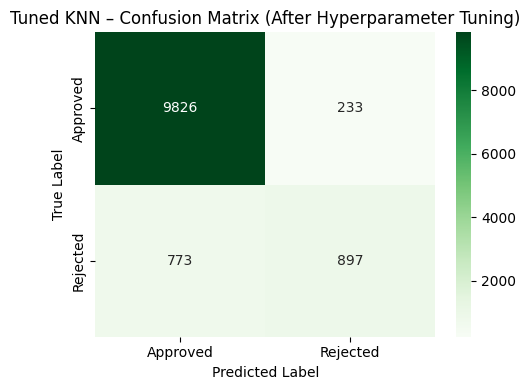

In [ ]:
# Compute the confusion matrix for the tuned KNN model
cm_best_knn = confusion_matrix(y_test, y_pred_best_knn)

# Plot the confusion matrix as a heatmap
# Green colour used to visually distinguish the tuned model from untuned models
plt.figure(figsize=(5, 4))
sns.heatmap(cm_best_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])

# Add title and axis labels
plt.title('Tuned KNN – Confusion Matrix (After Hyperparameter Tuning)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Step 12c – Before vs After Tuning Comparison

In [ ]:
# Import additional metrics for the comparison table
from sklearn.metrics import f1_score, precision_score, recall_score

# Before tuning metrics using k=5
acc_before = round(accuracy_score(y_test, y_pred_knn), 4)
f1_before = round(f1_score(y_test, y_pred_knn), 4)
precision_before = round(precision_score(y_test, y_pred_knn), 4)
recall_before = round(recall_score(y_test, y_pred_knn), 4)

# After tuning metrics using best k from GridSearchCV
acc_after = round(accuracy_score(y_test, y_pred_best_knn), 4)
f1_after = round(f1_score(y_test, y_pred_best_knn), 4)
precision_after = round(precision_score(y_test, y_pred_best_knn), 4)
recall_after = round(recall_score(y_test, y_pred_best_knn), 4)

# Build comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score (Approved)', 'Precision (Approved)', 'Recall (Approved)'],
    'Before Tuning (k=5)': [acc_before, f1_before, precision_before, recall_before],
    'After Tuning': [acc_after, f1_after, precision_after, recall_after]
})

print("KNN – Before vs After Hyperparameter Tuning")
print(comparison.to_string(index=False))

KNN – Before vs After Hyperparameter Tuning
              Metric  Before Tuning (k=5)  After Tuning
            Accuracy               0.9142        0.9142
 F1 Score (Approved)               0.6443        0.6407
Precision (Approved)               0.7867        0.7938
   Recall (Approved)               0.5455        0.5371


Peer Code Review Record
Code Reuse Session 2 – Classification Modelling and Hyperparameter Tuning (Week 5)

Notebook Author: Shane Rowell

Peer Reviewer: Dasika Ruvishan

Date of Review: 19/03/2026

Tests checked during peer review:

- Test 1: Dasika confirmed that all three models were trained and evaluated
  correctly and that confusion matrices, classification reports and AUC scores
  are present for each model with no missing outputs.

- Test 2: Dasika verified that feature scaling was applied correctly by
  confirming the scaler was fitted on training data only and then applied
  to the test set separately to prevent data leakage.

- Test 3: Dasika confirmed that hyperparameter tuning was carried out using
  GridSearchCV with F1 scoring and that the before and after comparison table
  correctly documents the performance metrics for the approved class before
  and after tuning.